# *TCC José Augusto* - Orientado por: *Arthur Carosia*
##Tema:
- Análise comparativa de eficácia em diferentes técnicas de Machine Learning na previsão de evasão escolar.

---


##Dados:
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

##Legenda:
https://docs.google.com/document/d/13sUMbGfYDHspFIwPNtN1eLm9i_W8zkXO735es3e_uaI/edit?usp=sharing

---

# Importação e limpeza dos dados (se necessário)

In [ ]:
# ------------ Bibliotecas -------------
# Gerais
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Algoritmos de teste
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, precision_score, recall_score, f1_score
# Decision Tree
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
# Regressão Logística
from sklearn.linear_model import LogisticRegression
# SVM
from sklearn.svm import SVC
# Rede Neural Artificial
from sklearn.neural_network import MLPClassifier

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/_TCC/data.csv", sep = ';')
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


Correções nas variáveis

In [ ]:
# Coluna "Daytime/evening attendance\t" tem esse '\t' no final que pode atrapalhar variáveis no futuro, vou remover esse '\t'.


df.columns = [col.strip().replace('\t', '') for col in df.columns]
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


# Gráficos pré previsão


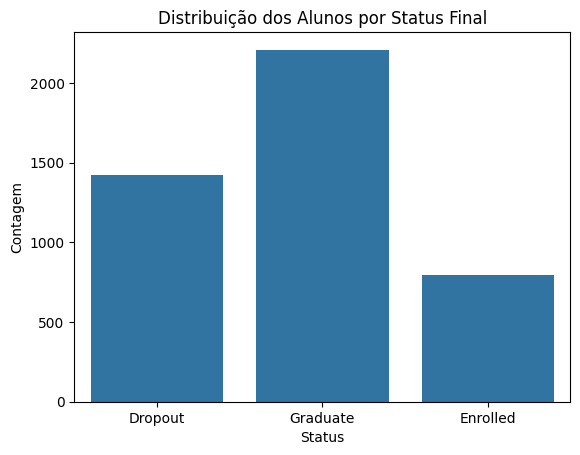

In [ ]:
# Compração de quantidade de alunos Evadidos (Dropout), Graduados (Graduate) e Matriculados (Enrolled).
sns.countplot(data=df, x='Target')
plt.title("Distribuição dos Alunos por Status Final")
plt.xticks(rotation=0)
plt.ylabel("Contagem")
plt.xlabel("Status")
plt.show()

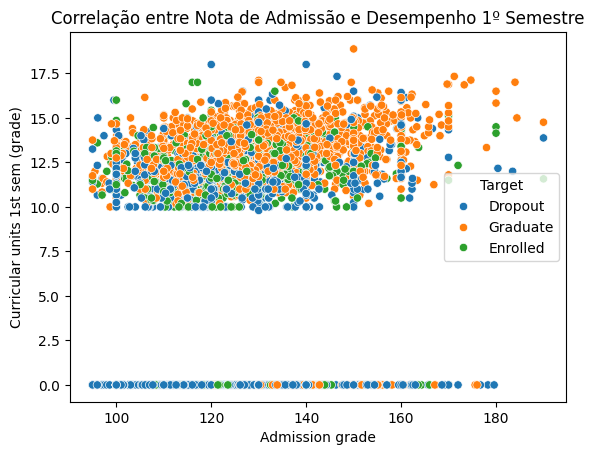

In [ ]:
sns.scatterplot(data=df, x='Admission grade', y='Curricular units 1st sem (grade)', hue='Target')
plt.title("Correlação entre Nota de Admissão e Desempenho 1º Semestre")
plt.show()

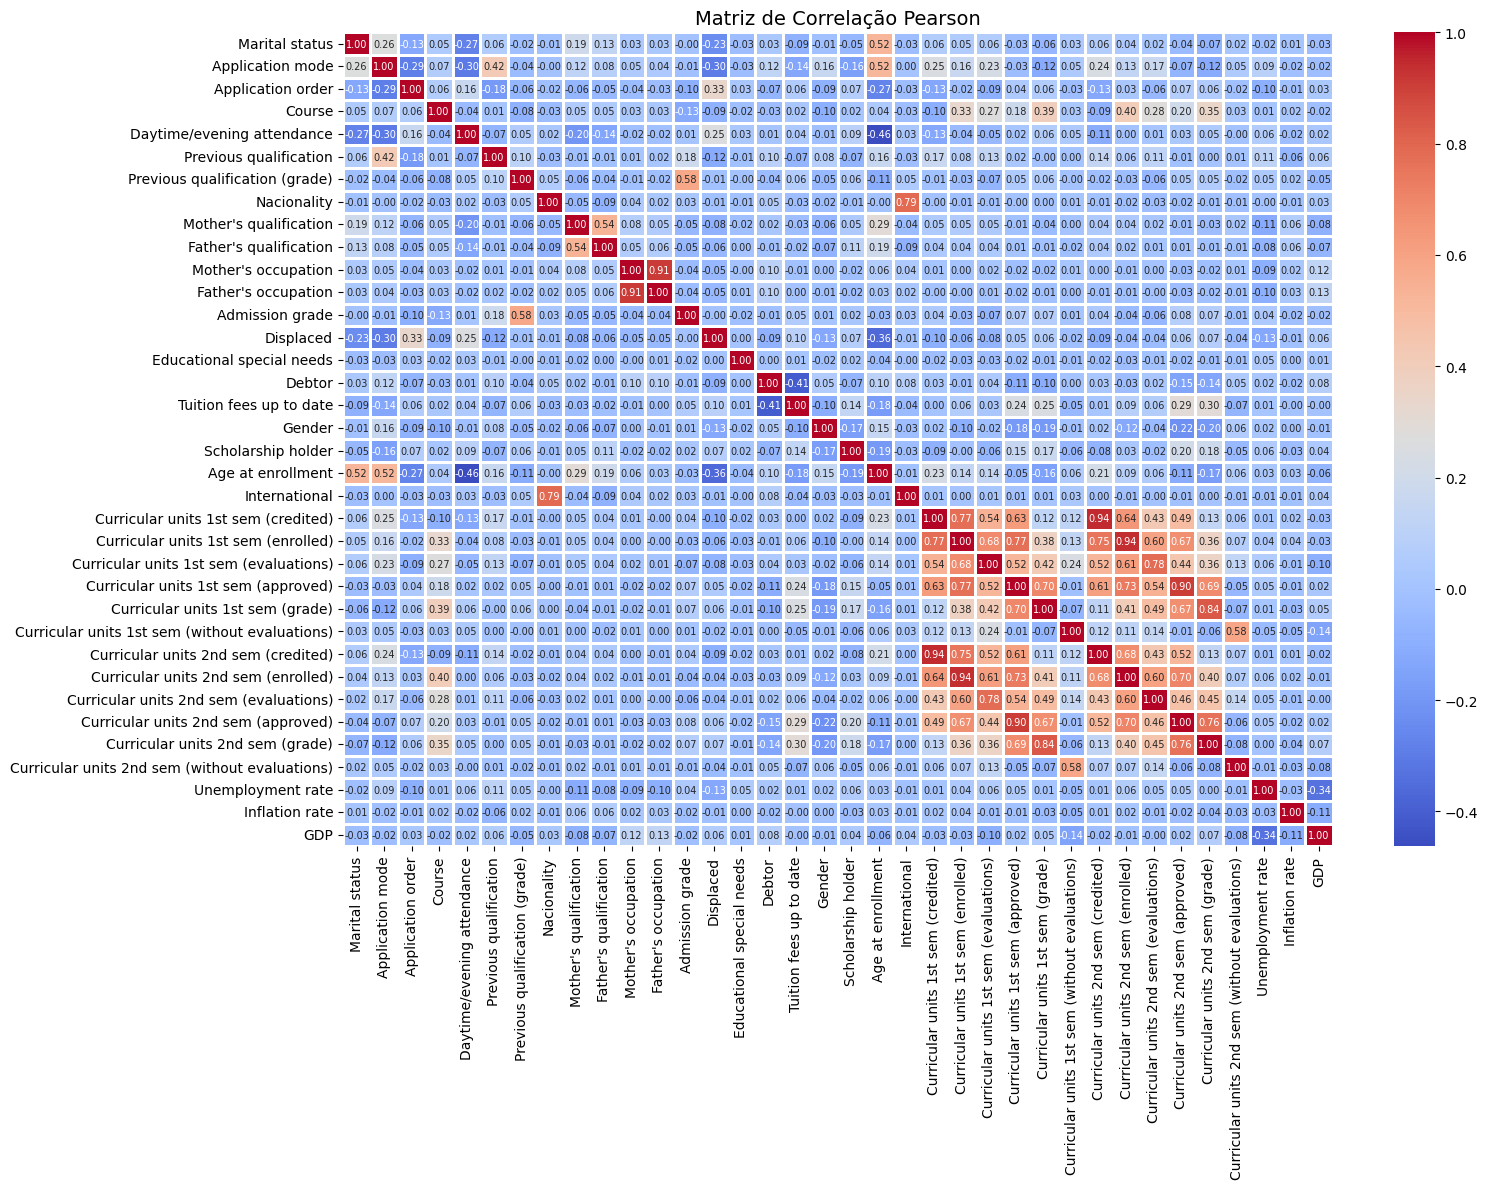

In [ ]:
# Pearson
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(16, 12))  # Aumenta o tamanho do gráfico
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.8,              # Espaço entre células
    annot_kws={'size': 7}       # Tamanho dos números
)
plt.title("Matriz de Correlação Pearson", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()  # Ajusta tudo para caber bem
plt.show()

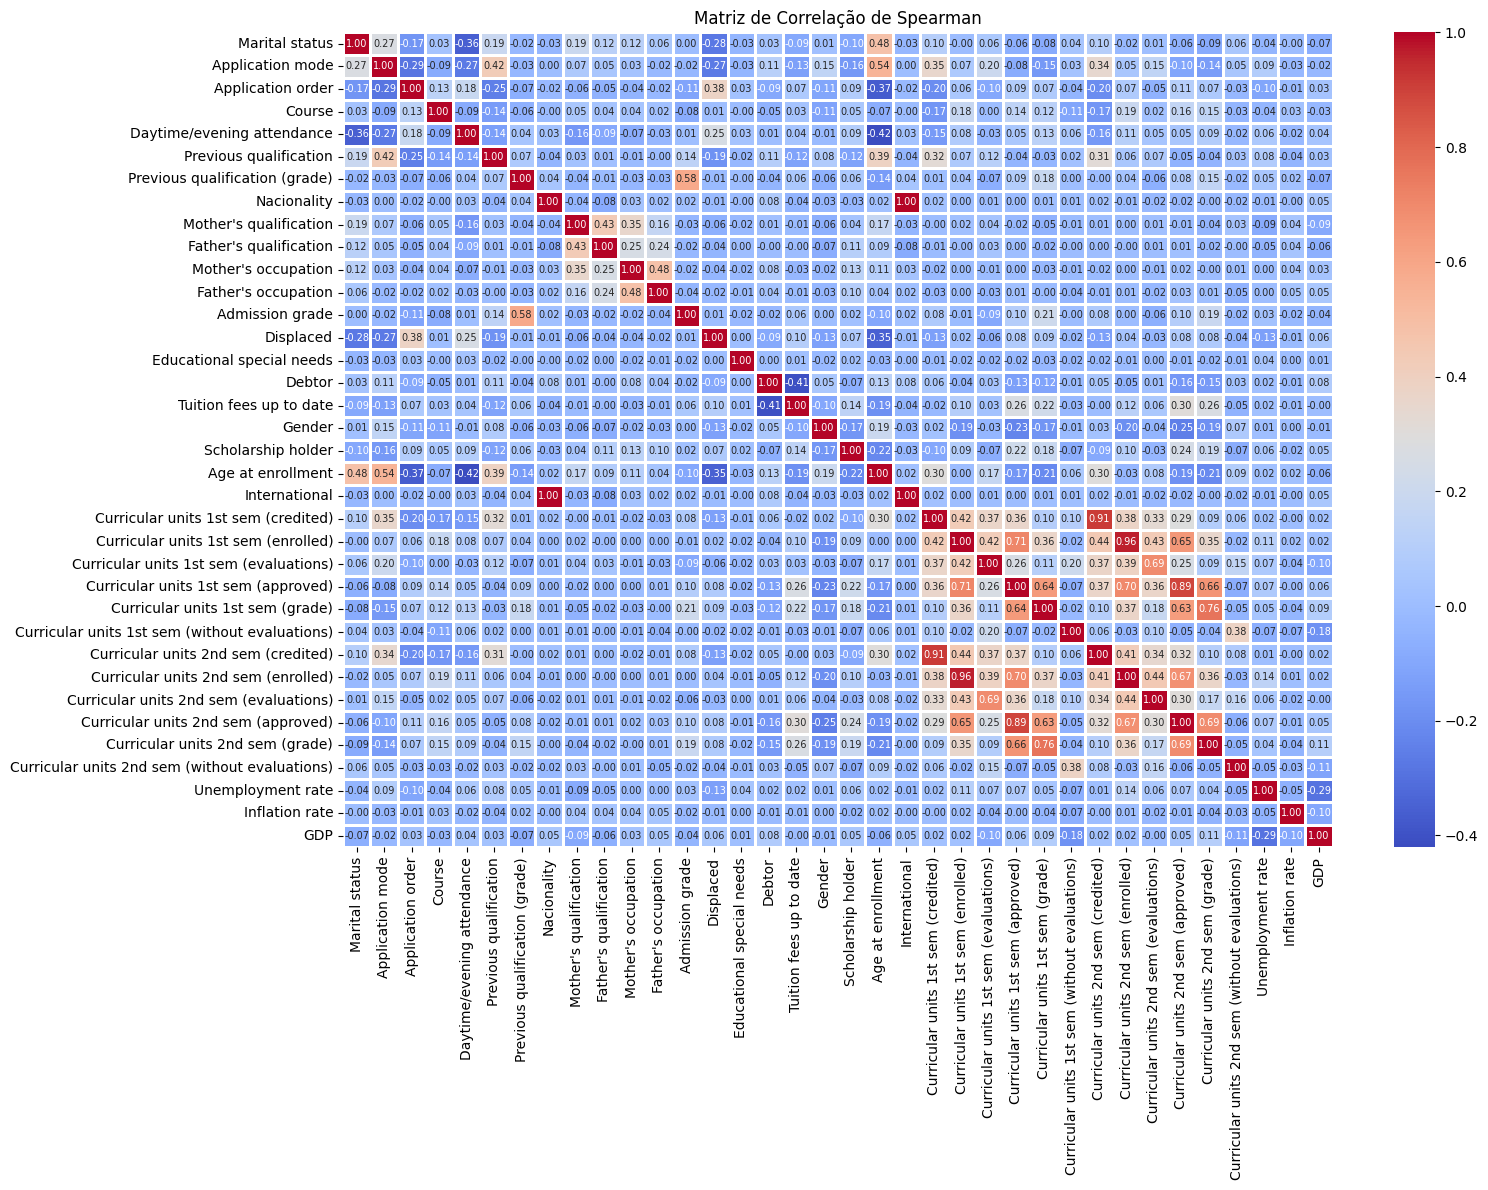

In [ ]:
# Spearman
corr_spearman = df.select_dtypes(include=np.number).corr(method='spearman')

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.8,
    annot_kws={'size': 7}
)
plt.title("Matriz de Correlação de Spearman")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


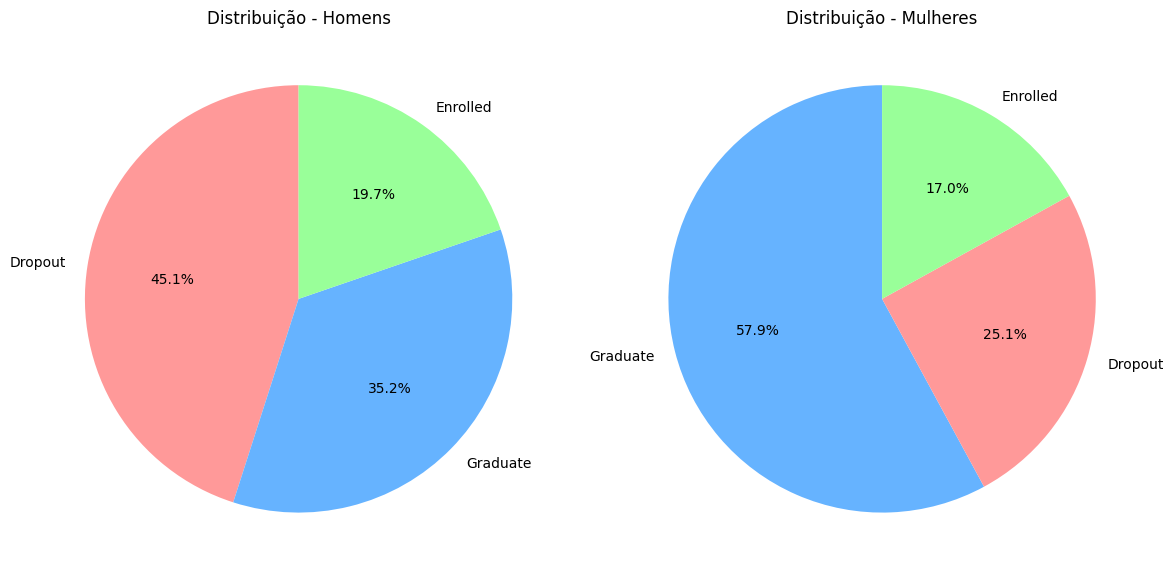

In [ ]:
# Filtros
male_data = df[df['Gender'] == 1]['Target'].value_counts()
female_data = df[df['Gender'] == 0]['Target'].value_counts()

# Cores
colors = ['#ff9999','#66b3ff','#99ff99']
colors_m = ['#ff9999','#66b3ff','#99ff99']
colors_f = ['#66b3ff','#ff9999','#99ff99']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico masculino
axes[0].pie(male_data, labels=male_data.index, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Distribuição - Homens')

# Gráfico feminino
axes[1].pie(female_data, labels=female_data.index, autopct='%1.1f%%', startangle=90, colors=colors_f)
axes[1].set_title('Distribuição - Mulheres')

# Garante que os círculos sejam perfeitos
plt.tight_layout()
plt.show()


# Desenvolvimento prático - Metodologia: Algoritmos de previsão.

In [ ]:
# Árvore de decisão (Decision Tree)

# ---------------------- Criando o modelo ----------------------
X = df.drop("Target", axis=1)  # Todas as colunas menos a Target
y = df["Target"] # Apenas a coluna Target

#Divisão modelo/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Criando a arvore
modelo_dt = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)
modelo_dt.fit(X_train, y_train)

# ------------------------- Previsões e Avaliação --------------------
y_pred = modelo_dt.predict(X_test) # previsão

print("+++ Árvore de Decisão (Decision Tree) +++\n")
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação: \n\n", classification_report(y_test, y_pred)) # avaliação de acurácia

+++ Árvore de Decisão (Decision Tree) +++

Acurácia: 0.7310734463276836

Relatório de Classificação: 

               precision    recall  f1-score   support

     Dropout       0.85      0.68      0.76       316
    Enrolled       0.42      0.34      0.37       151
    Graduate       0.75      0.91      0.82       418

    accuracy                           0.73       885
   macro avg       0.67      0.64      0.65       885
weighted avg       0.73      0.73      0.72       885



Acurácia: 0.7604519774011299

Relatório de classificação:
               precision    recall  f1-score   support

     Dropout       0.85      0.77      0.81       316
    Enrolled       0.49      0.30      0.37       151
    Graduate       0.76      0.92      0.83       418

    accuracy                           0.76       885
   macro avg       0.70      0.66      0.67       885
weighted avg       0.75      0.76      0.74       885



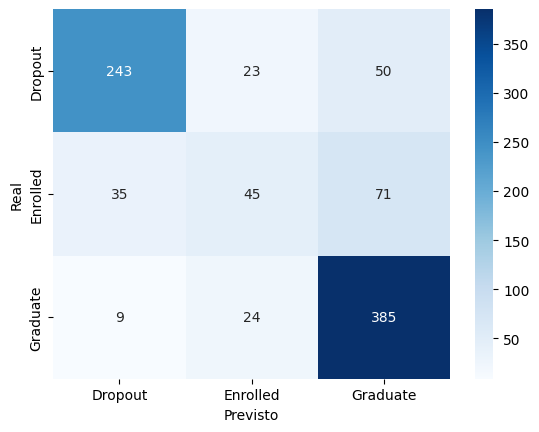

In [ ]:
# Floresta Aleatória (Random Forest)

# ---------------------- Criando o modelo ----------------------
X = df.drop("Target", axis=1)
y = df["Target"]

# Transformar o Target em números
le = LabelEncoder()
y = le.fit_transform(y) # (Exemplo: Dropout=0, Enrolled=1, Graduate=2)

# Divisão modelo/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo_rf = RandomForestClassifier(
    n_estimators=100,      # número de árvores
    max_depth=None,        # profundidade das árvores
    random_state=42,
    n_jobs=-1              # usa todos os núcleos do processador
)

modelo_rf.fit(X_train, y_train)
y_pred = modelo_rf.predict(X_test)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de classificação:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Matriz de confusão
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()




/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Acurácia: 0.7265536723163842

Relatório de Classificação:
               precision    recall  f1-score   support

     Dropout       0.73      0.71      0.72       284
    Enrolled       0.48      0.26      0.34       159
    Graduate       0.77      0.90      0.83       442

    accuracy                           0.73       885
   macro avg       0.66      0.63      0.63       885
weighted avg       0.70      0.73      0.71       885


Matriz de Confusão:
 [[203  28  53]
 [ 49  42  68]
 [ 26  18 398]]


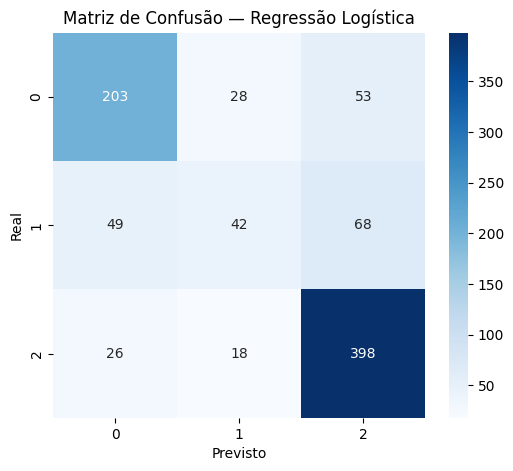

In [ ]:
# Regressão Logistica

# 1. Copiar o DataFrame original
dados = df.copy()

# 2. Definir X (variáveis independentes) e y (variável alvo)
X = dados.drop('Target', axis=1)
y = dados['Target']

# 3. Dividir a base em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Criar e treinar o modelo de Regressão Logística
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# 5. Fazer previsões
y_pred = modelo.predict(X_test)

# 6. Avaliar o modelo
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))

# 7. Visualizar a matriz de confusão
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão — Regressão Logística")
plt.show()

In [ ]:
# Support Vector Machine (SVM)

# Separar as variáveis (X) e o alvo (y)
X = df.drop(columns=['Target'])
y = df['Target']

# Dividir em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Criar e treinar o modelo SVM
svm = SVC(kernel='linear', random_state=42) #Criação
svm.fit(X_train, y_train) # Treino
y_pred = svm.predict(X_test) # Previsão

# Avaliar o desempenho
print("\n--- SUPPORT VECTOR MACHINE ---")
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1-score:", f1_score(y_test, y_pred, average='macro'))


# Testes de kernel
# # Teste 1 — Kernel linear - 0.75
# modelo_linear = SVC(kernel='linear', random_state=42)
# modelo_linear.fit(X_train, y_train)
# print("Acurácia (Linear):", modelo_linear.score(X_test, y_test))

# # Teste 2 — Kernel polinomial (grau 3) - 0.48
# modelo_poly = SVC(kernel='poly', degree=3, random_state=42)
# modelo_poly.fit(X_train, y_train)
# print("Acurácia (Poly grau 3):", modelo_poly.score(X_test, y_test))

# # Teste 3 — Kernel RBF - 0.48
# modelo_rbf = SVC(kernel='rbf', random_state=42)
# modelo_rbf.fit(X_train, y_train)
# print("Acurácia (RBF):", modelo_rbf.score(X_test, y_test))

# # Teste 4 — Kernel Sigmoid - 0.46
# modelo_sigmoid = SVC(kernel='sigmoid', random_state=42)
# modelo_sigmoid.fit(X_train, y_train)
# print("Acurácia (Sigmoid):", modelo_sigmoid.score(X_test, y_test))



--- SUPPORT VECTOR MACHINE ---
Acurácia: 0.7537650602409639
Precisão: 0.6980741543209009
Recall: 0.6536411864849782
F1-score: 0.6548056184899398


In [ ]:
# Rede Neural Artificial (ANN)

# Separar as variáveis (X) e o alvo (y)
X = df.drop(columns=['Target'])
y = df['Target']

# Dividir em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Criar a Rede Neural
# hidden_layer_sizes define o número de camadas e neurônios em cada uma
mlp = MLPClassifier(hidden_layer_sizes=(5,5,5,5,5,5,5,5), max_iter=1000, random_state=42)

# Treinar o modelo
mlp.fit(X_train, y_train)

# Fazer previsões
y_pred = mlp.predict(X_test)

# Avaliar o desempenho
print("\n--- REDE NEURAL ARTIFICIAL ---")
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1-score:", f1_score(y_test, y_pred, average='macro'))


--- REDE NEURAL ARTIFICIAL ---
Acurácia: 0.7213855421686747
Precisão: 0.6081328624502517
Recall: 0.6101765316718587
F1-score: 0.5982947584202979


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Separar as variáveis (X) e o alvo (y)
X = df.drop(columns=['Target'])
y = df['Target']

# Dividir em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ---------------------------------------------------------
# 🔥 DEFINIR OS HIPERPARÂMETROS QUE SERÃO TESTADOS
# ---------------------------------------------------------

param_dist = {
    'hidden_layer_sizes': [
        (5,5,5,5),
        (10,10,10),
        (20,10),
        (30,30,30),
        (50,20,10),
        (5,5,5,5,5,5,5,5),
        (32,32),
        (64,32),
        (100,),
    ],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': [0.1, 0.01, 0.001, 0.0001],
    'batch_size': [8, 16, 32, 64],
    'max_iter': [1000]
}

random_search = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

# Treinar o Random Search
random_search.fit(X_train, y_train)

# Melhor modelo encontrado
best_mlp = random_search.best_estimator_

print("\nMelhores hiperparâmetros encontrados:")
print(random_search.best_params_)

y_pred = best_mlp.predict(X_test)

print("\n--- MELHOR REDE NEURAL (ENCONTRADA AUTOMATICAMENTE) ---")
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1-score:", f1_score(y_test, y_pred, average='macro'))



Melhores hiperparâmetros encontrados:
{'solver': 'adam', 'max_iter': 1000, 'learning_rate_init': 0.0001, 'hidden_layer_sizes': (5, 5, 5, 5, 5, 5, 5, 5), 'batch_size': 16, 'activation': 'relu'}

--- MELHOR REDE NEURAL (ENCONTRADA AUTOMATICAMENTE) ---
Acurácia: 0.7341867469879518
Precisão: 0.6916944674642131
Recall: 0.62055368357104
F1-score: 0.619847071428477


In [ ]:
# Exemplo genérico de previsão com Random Forest
# Funciona para regressão. Para classificação, veja comentário no final.

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Carregar dados
df = pd.read_csv("dados.csv")

# 2. Separar variáveis explicativas e alvo
# Troque "target" pelo nome da coluna que você quer prever
X = df.drop(columns=["target"])
y = df["target"]

# 3. Tratar variáveis categóricas, se houver
X = pd.get_dummies(X, drop_first=True)

# 4. Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 5. Criar e treinar o modelo
modelo = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

# 6. Fazer previsões
y_pred = modelo.predict(X_test)

# 7. Avaliar o modelo
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# 8. Prever novos dados
novo_dado = pd.DataFrame({
    "coluna1": [10],
    "coluna2": [5],
    "coluna3": ["categoria_a"]
})

# Aplicar o mesmo one-hot encoding
novo_dado = pd.get_dummies(novo_dado, drop_first=True)

# Garantir que tenha as mesmas colunas do treino
novo_dado = novo_dado.reindex(columns=X.columns, fill_value=0)

previsao = modelo.predict(novo_dado)

print("Previsão:", previsao)